# F1 — Frozen Forecasting Model Comparison

Overlays the three frozen baselines' 7-day rolling MAE on the same axes, per region, so their degradation can be compared directly:

| line | source notebook / script | forecast |
| --- | --- | --- |
| **Seasonal naive (lag 48)** | [`seasonal_naive_baseline.ipynb`](seasonal_naive_baseline.ipynb) | $\hat{y}_t = y_{t-48}$ — 1-day-ahead, using arrived actuals |
| **DHR + ARIMA** | [`dhr_arima_real.py`](../../src/drift_forecasting/forecasting/classical-model/dhr_arima_real.py) | frozen multi-step forecast from the end of training |
| **XGBoost (lag + calendar)** | [`xgboost_baseline.ipynb`](xgboost_baseline.ipynb) | frozen recursive multi-step forecast from the end of training |

All three are computed on the same frozen test split (`2020-03-01` → `2024-01-01`, 67,249 half-hourly intervals) with the same 7-day rolling window (`min_periods = 336`), so the first 335 test intervals are NaN for every line.

**Caveat when reading the plots:** the seasonal-naive line is *not* the same forecasting task as the other two — it re-anchors on the observation exactly one day earlier, whereas DHR+ARIMA and XGBoost extrapolate from the training window without ever seeing a test value. Seasonal naive therefore sits lower for reasons unrelated to drift-robustness.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from drift_forecasting.config import DATA_DIR, REGIONS, ROOT_DIR


## 1. Load the three frozen baselines

Each model writes a per-region CSV containing at least a `SETTLEMENTDATE` column and its 7-day rolling MAE. The seasonal-naive and XGBoost notebooks write a 5-column table (`ROLLING_MAE_7D`); the classical script writes a 2-column table (`mae`). This cell normalises all of them to a single `Series` of rolling MAE indexed by timestamp.

In [2]:
# Where each model's per-region rolling-MAE CSV lives, and how to draw it.
TIMESTAMP_COLUMN = "SETTLEMENTDATE"
CLASSICAL_DIR = ROOT_DIR / "src" / "drift_forecasting" / "forecasting" / "classical-model"

OUTPUT_DIR = DATA_DIR / "baseline" / "comparison"   # figures written here
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {  # key -> plot label + line colour, shared by every figure below
    "seasonal_naive": {"label": "Seasonal naive (lag 48)", "color": "tab:green"},
    "classical":      {"label": "DHR + ARIMA",             "color": "tab:orange"},
    "xgboost":        {"label": "XGBoost (lag + calendar)", "color": "tab:blue"},
}


def model_csv(key: str, region: str) -> Path:
    """Path to one model's rolling-MAE CSV for one region."""
    if key == "classical":
        return CLASSICAL_DIR / f"{region}_rolling_mae.csv"        # written by dhr_arima_real.py
    return DATA_DIR / "baseline" / key / f"{region}_{key}_test.csv"  # written by the two notebooks


def load_rolling_mae(key: str, region: str) -> pd.Series:
    """Read one model/region CSV and return its 7-day rolling MAE as a timestamp-indexed Series."""
    path = model_csv(key, region)
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found - run the {key} notebook / script first"
        )
    df = pd.read_csv(path, parse_dates=[TIMESTAMP_COLUMN])
    mae_column = "mae" if key == "classical" else "ROLLING_MAE_7D"  # classical CSV uses a different name
    return pd.Series(
        df[mae_column].to_numpy(),
        index=pd.DatetimeIndex(df[TIMESTAMP_COLUMN]),
        name=MODELS[key]["label"],
    )


# curves[region][key] -> that model's rolling-MAE Series; the single source for every plot/table.
curves = {
    region: {key: load_rolling_mae(key, region) for key in MODELS}
    for region in REGIONS
}

# Sanity check: all three models should share the same 67,249-row index with 335 leading NaN.
for region in REGIONS:
    print(region)
    ref_index = curves[region]["seasonal_naive"].index
    for key, series in curves[region].items():
        aligned = series.index.equals(ref_index)
        print(
            f"  {MODELS[key]['label']:<26} {len(series):,} rows, "
            f"{int(series.isna().sum())} leading NaN, "
            f"first value {series.first_valid_index()}, "
            f"index matches seasonal-naive: {aligned}"
        )


SA1
  Seasonal naive (lag 48)    67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  DHR + ARIMA                67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  XGBoost (lag + calendar)   67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
NSW1
  Seasonal naive (lag 48)    67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  DHR + ARIMA                67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  XGBoost (lag + calendar)   67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True


## 2. Numeric comparison

**What the table is:** one row per (region, model). `mean` / `median` / `max` are over the whole post-warm-up test stream (MW of 7-day rolling MAE); the year columns are the mean within each calendar year.

**What to read from it:**

- **Ranking is stable in both regions:** seasonal naive lowest, XGBoost in the middle, DHR+ARIMA highest — and the gap is large (NSW1: 441 vs 744 vs 880). The two learned models are frozen at end-2019 and never see a test value, so this is the price of not adapting.
- **The year columns only go up.** Every model's yearly mean is higher in 2023 than in 2020 (NSW1 DHR+ARIMA 814 → 938; SA1 XGBoost 183 → 255). None of the three ever has a better year than its first — consistent with drift that accumulates and never reverses.
- Seasonal naive drifts least (SA1 flat ~154–158; NSW1 +10 %), which is why it is the reference line for "no adaptation, but also barely degrading".

The rest of section 3 is about *when* within those years the error steps up.

In [3]:
# All calendar years that appear anywhere in the (post-warm-up) rolling-MAE series.
ALL_YEARS = sorted({
    ts.year
    for region in REGIONS
    for series in curves[region].values()
    for ts in series.dropna().index
})
# Keep only years covered by every model in both regions (drops 2024: one lone timestamp).
TEST_YEARS = [
    year
    for year in ALL_YEARS
    if all(
        (series.dropna().index.year == year).sum() >= 2
        for region in REGIONS
        for series in curves[region].values()
    )
]

# One row per (region, model): whole-period mean/median/max, then the mean within each year.
rows = []
for region in REGIONS:
    for key, spec in MODELS.items():
        series = curves[region][key].dropna()   # drop the 335 warm-up NaN
        row = {
            "region": region,
            "model": spec["label"],
            "mean": series.mean(),
            "median": series.median(),
            "max": series.max(),
        }
        for year in TEST_YEARS:
            row[str(year)] = series[series.index.year == year].mean()  # per-year mean MAE
        rows.append(row)

summary = pd.DataFrame(rows)
display(summary.round(1))


,region,model,mean,median,max,2020,2021,2022,2023
0,SA1,Seasonal naive (lag 48),155.9,148.2,389.7,153.7,153.9,158.3,157.2
1,SA1,DHR + ARIMA,237.3,234.4,450.7,216.1,229.2,241.2,259.0
2,SA1,XGBoost (lag + calendar),219.7,212.8,515.9,182.7,192.5,241.6,255.3
3,NSW1,Seasonal naive (lag 48),441.4,415.5,1041.6,422.6,432.5,440.6,466.6
4,NSW1,DHR + ARIMA,880.2,844.0,1635.8,814.5,866.0,890.7,937.7
5,NSW1,XGBoost (lag + calendar),743.7,684.4,1657.1,683.3,696.9,767.2,816.4


## 3. The whole test period, and where the models break

First, one 4-year rolling-MAE figure per region with all three models overlaid. Then:

- **3a** — how the **degradation windows** (the blue bands in section 4) are found, with the evidence behind each one.
- **3b** — a year-by-year check of whether each seasonal spike unwinds or sticks.

Quick definition, spelled out in 3a: a **degradation window** is the short *rising edge* where a model's error leaves its normal level and settles onto a worse one. It is **not** the peak, the long elevated stretch, or the eventual recovery — just the transition.

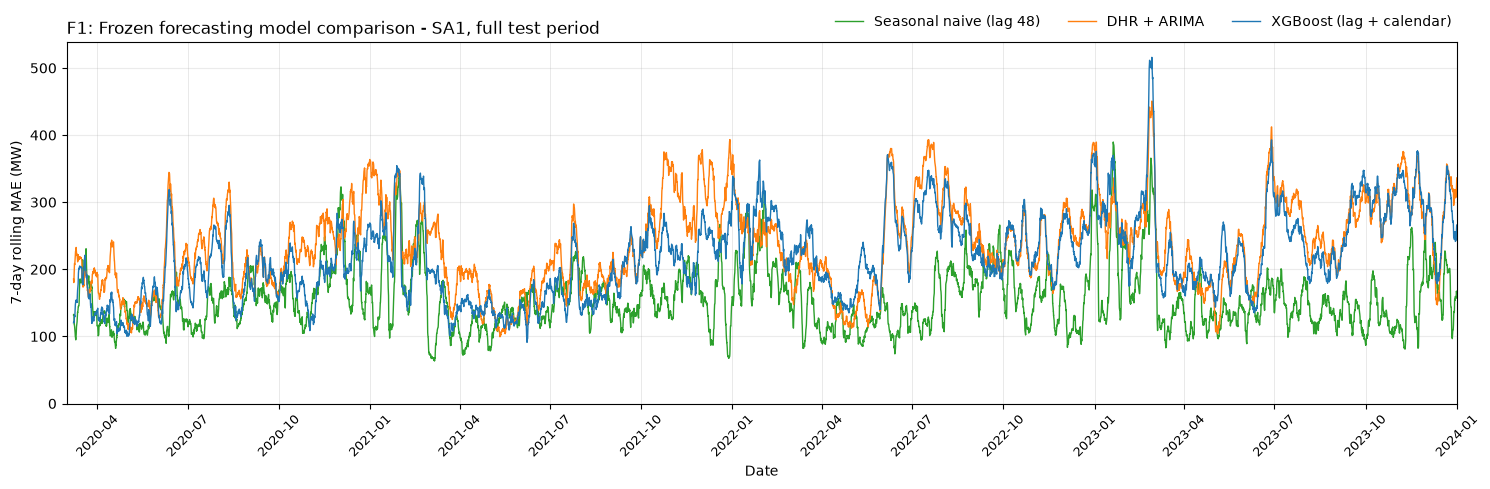

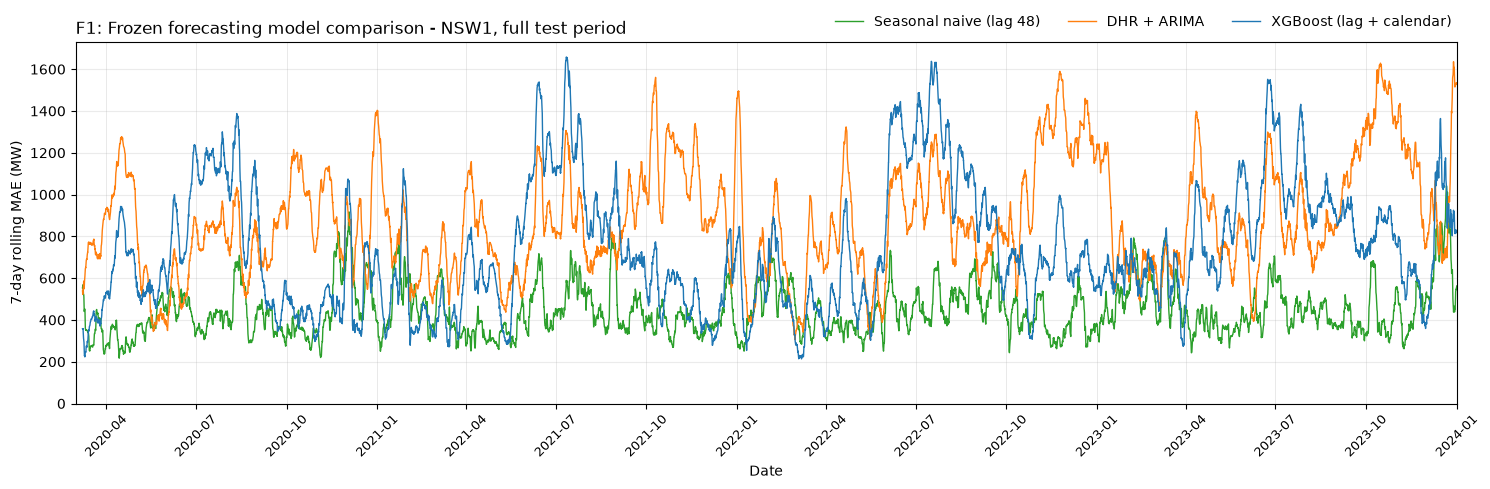

In [4]:
PERIOD_START = pd.Timestamp("2020-03-01")   # x-axis limits for the full-period panels
PERIOD_END = pd.Timestamp("2024-01-01")


def plot_full_period(region: str) -> None:
    """Draw and save the 4-year rolling-MAE panel for one region (all three models overlaid)."""
    fig, ax = plt.subplots(figsize=(15, 5))

    for key, spec in MODELS.items():   # one coloured line per model
        series = curves[region][key]
        ax.plot(series.index, series.values, label=spec["label"],
                color=spec["color"], linewidth=1.0)

    ax.set_title(
        f"F1: Frozen forecasting model comparison - {region}, full test period",
        loc="left",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("7-day rolling MAE (MW)")
    ax.set_xlim(PERIOD_START, PERIOD_END)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # quarterly ticks
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.grid(alpha=0.25)
    ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.02),   # legend above the axes
              ncol=len(MODELS), frameon=False, borderaxespad=0.0)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"f1_comparison_{region}_full.png",
                dpi=130, bbox_inches="tight")
    plt.show()


for region in REGIONS:
    plot_full_period(region)


**Reading the full-period panels — one model at a time.**

**Seasonal naive — lowest, and least volatile.** It predicts "same time yesterday" from the value that just arrived, so it never wanders far from its floor (~110 MW SA1, ~300 MW NSW1). It has the same seasonal cycle as the others, but its peaks are short and it snaps back within weeks; the floor barely moves (SA1 flat 2020→2023, NSW1 creeps ~+20 %). *What it shows:* effectively **no drift** — a mild rooftop-solar creep on NSW1, plus one unresolved spike at each region's data end.

**XGBoost — middle of the pack, but the sharpest peaks.** A frozen recursive forecast: past the first day it runs on 2018–2019 lag-and-calendar climatology. It tracks the daily/weekly shape well but badly overshoots the seasonal swings it never learned — NSW1's winter error reaches **3.6× its floor**, the single biggest jump anywhere. *What it shows:* recurring winter/summer degradation that clears at the next autumn through 2020–2021, then **stops clearing** from around summer 2021–22 (SA1) / winter 2022 (NSW1), each episode leaving the autumn floor higher (SA1 127→184, NSW1 391→564).

**DHR + ARIMA — highest, and wrong for the longest.** A pure multi-step Fourier + ARIMA forecast with only daily and weekly terms — no annual component — so it is structurally blind to yearly seasonality and sits above its floor most of the year; it is also the noisiest line. *What it shows:* degraded from its very first test winter — **NSW1 never returns to its May-2020 low** — and a floor that ratchets up across the run (NSW1 465→643, SA1 140→161).

**Common to all three:** the seasonal shape and the big excursions line up across models, so those are real demand behaviour, not model artefacts. Without ground truth we can't say how many distinct drifts the rising floors represent — §3a is a shortlist, not a count.

### 3a. Finding the degradation windows — the method

**What we're looking for.** Every model's rolling-MAE curve climbs each winter and each summer and then falls back — that is just the seasons, and the frozen models simply handle some seasons worse than others. On its own, that is *not* drift. **Drift is when the error climbs and then does *not* fully come back** — the model has shifted onto a permanently worse level and stayed there.

The blue band should mark only the **moment of that shift**: the short rising edge where the error leaves its old level and settles onto the new one. The peak that follows, the months it spends elevated, and any later partial recovery are the *aftermath*, not the event — so they are left out of the band.

Everything below runs on each model separately, per region. The exact numbers are constants at the top of the next cell; the reasoning is here.

**Step 1 — Clean up the curve.** We begin with the model’s 7 day rolling MAE. This is converted into one value per day and then averaged over approximately 28 days. This reduces temporary fluctuations caused by weekends, holidays or unusual weather. It makes sustained changes in model performance easier to see.

**Step 2 — Define what "normal" means for this model, right now.** Each model has a different error scale, so one fixed MAE threshold cannot be used for every model. Instead, we estimate a recent normal error level called the calm floor. It is calculated using the lowest 20 percent of the smoothed errors from the previous 90 days. The calm floor is shifted back by 21 days. This prevents a new error increase from immediately raising its own reference level.

**Step 3 — Find the bumps ("episodes").** A day is considered elevated when its smoothed error is more than 35 percent above the calm floor. Consecutive elevated days are grouped into an episode. An episode is kept as a candidate only if it lasts for at least 18 days and its highest error reaches at least 40 percent above the calm floor. This removes small or temporary error spikes.

**Step 4 — Keep only the bumps that stuck.** After the episode ends, we examine the model’s error from 10 to 75 days later. If the median error during this period is still at least 15 percent above the old calm floor, the increase is considered persistent. If the error returns close to its previous level, the episode is treated as a temporary or seasonal increase and is discarded.

**Step 5 — Pin down where the rise began (the onset).** The 35 percent threshold identifies an episode only after the error has already started increasing. The method therefore searches backward up to 63 days from the start of the episode. The degradation onset is the last day when the error was still within 15 percent of the old calm floor. This date becomes the beginning of the blue degradation window.

**Step 6 — Pin down where the model had clearly broken (the window end).** Starting from the onset, the method searches forward for the first day when the error reaches 50 percent above the old calm floor. This date becomes the end of the degradation window. If the increase occurs in fewer than three days, a seven day window is used so that the change remains visible on the graph. The blue window therefore shows only the transition from normal performance to clearly worse performance. It does not cover the entire period of elevated error.

The stretch from **onset → clearly broken** is the **degradation window** — the blue band. It comes out one to eight weeks wide.

**Step 7 — Combine the three models.** Steps 1–6 give a set of windows for each model. We draw a blue band wherever *any* one model has a window, and merge bands that start within a week of each other, so one seasonal turn shows as a single band instead of three overlapping ones.

**Difference between an episode and a degradation window**

An episode is the longer period during which the error remains more than 35 percent above normal. It is used to locate and test possible degradation. A degradation window is shorter. It covers only the transition from the old error level to the clearly elevated error level. Only this shorter period is shown in blue.

**Worked example — SA1, DHR + ARIMA, first winter 2020.** The calm floor in mid-May is about 148 MW. The smoothed error is last on that floor on **29 May**, and first reaches 50 % above it (~222 MW) on **16 June** → window **29 May → 16 June**. Three months after the winter episode ends the error is still ~1.4× the old floor, so the "did it stick?" test passes and the window is kept.

In [5]:
# ============================================================================
#  Degradation-window detector  --  the 7 steps from 3a, made concrete
# ============================================================================
#  Every threshold from the 3a reasoning, in one place. "floor" below always
#  means the calm floor from step 2 (the model's recent normal error level).
SMOOTH_WINDOW_DAYS   = 28     # step 1: width of the centred average over the daily error
FLOOR_LOOKBACK_DAYS  = 90     # step 2: "recent" = the last ~3 months
FLOOR_PERCENTILE     = 0.20   # step 2: the calm floor is this quantile of that window
FLOOR_LAG_DAYS       = 21     # step 2: hold the floor 3 weeks back so a fresh rise can't lift it

EPISODE_RATIO        = 1.35   # step 3: a day is "elevated" if smoothed error > this * floor
MIN_EPISODE_DAYS     = 18     # step 3: shorter elevated runs are blips, ignored
MIN_PEAK_RATIO       = 1.40   # step 3: the run must peak at least this * floor

STUCK_AFTER_START    = 10     # step 4: start looking this many days after the run ends
STUCK_AFTER_END      = 75     # step 4: ... up to this many days after
STUCK_RATIO          = 1.15   # step 4: median error there still >= this * floor  ->  it stuck

AT_FLOOR_RATIO       = 1.15   # step 5: "still at the old level" means <= this * floor
ONSET_LOOKBACK_DAYS  = 63     # step 5: walk back this far for the last day at the floor
DECISIVE_RATIO       = 1.50   # step 6: window ends the first day error reaches this * floor

MERGE_GAP_DAYS       = 7      # step 7: fuse windows whose starts are within a week


def smoothed_error_and_calm_floor(rolling_mae: pd.Series):
    """Steps 1-2: return (de-noised daily error curve, its trailing calm-floor curve)."""
    daily = rolling_mae.resample("D").mean().interpolate()                       # 1 point per day
    smoothed = daily.rolling(SMOOTH_WINDOW_DAYS, center=True, min_periods=10).mean()  # kill weekly wiggle
    calm_floor = (
        smoothed.rolling(FLOOR_LOOKBACK_DAYS, min_periods=40)
        .quantile(FLOOR_PERCENTILE)      # 20th percentile of the last ~3 months = "normal lately"
        .shift(FLOOR_LAG_DAYS)           # lag it so the current rise doesn't inflate its own baseline
    )
    return smoothed, calm_floor


def find_degradation_windows(rolling_mae: pd.Series) -> pd.DataFrame:
    """Steps 3-6 for one model: one row per surviving rising-edge window, with its evidence."""
    smoothed, calm_floor = smoothed_error_and_calm_floor(rolling_mae)

    # step 3: split the curve into runs of consecutive "elevated" days
    is_elevated = smoothed > EPISODE_RATIO * calm_floor
    run_id = (is_elevated != is_elevated.shift()).cumsum()   # a new id every time the flag flips

    windows = []
    for _, run in smoothed[is_elevated].groupby(run_id[is_elevated]):
        run_start, run_end = run.index[0], run.index[-1]
        if (run_end - run_start).days < MIN_EPISODE_DAYS:           # step 3: too short -> blip
            continue
        floor = calm_floor.loc[run_start]                           # the level it rose FROM
        if run.max() / floor < MIN_PEAK_RATIO:                      # step 3: jump too small
            continue

        # step 4: did the error stay up? look at the 10-75 days after the run ends
        after = smoothed.loc[
            run_end + pd.Timedelta(days=STUCK_AFTER_START):
            run_end + pd.Timedelta(days=STUCK_AFTER_END)
        ].median()
        if pd.isna(after) or after < STUCK_RATIO * floor:           # it recovered -> not degradation
            continue

        # step 5: walk back to the onset -- last day in the 9 weeks before the run still at the old floor
        before = smoothed.loc[run_start - pd.Timedelta(days=ONSET_LOOKBACK_DAYS): run_start]
        still_at_floor = before[before <= AT_FLOOR_RATIO * floor]
        onset = still_at_floor.index.max() if len(still_at_floor) else run_start

        # step 6: walk forward to the window end -- first day from the onset that the error is decisively elevated
        after_onset = smoothed.loc[onset:]
        decisive = after_onset[after_onset >= DECISIVE_RATIO * floor]
        elevated_by = decisive.index.min() if len(decisive) else run.idxmax()
        if (elevated_by - onset).days < 3:        # near-vertical jump -> give the band a nominal width
            elevated_by = onset + pd.Timedelta(days=7)

        windows.append(
            {
                "onset": onset,                                        # blue band start
                "elevated_by": elevated_by,                            # blue band end
                "calm floor (MW)": round(floor),                       # error level before
                "rose to (MW)": round(smoothed.loc[elevated_by]),      # error level at band end
                "jump": f"{smoothed.loc[elevated_by] / floor:.2f}x",   # ratio of the two
                "3 months later (MW)": round(after),                   # where it sat afterwards
                "3 months later": f"{after / floor:.2f}x",             # ... as a ratio of the floor
            }
        )

    table = pd.DataFrame(windows)
    if len(table):                          # step 7 (within a model): fuse windows that nearly touch
        table = _merge_windows(table)
        table.insert(2, "days", (table["elevated_by"] - table["onset"]).dt.days)
    return table


def _merge_windows(table: pd.DataFrame) -> pd.DataFrame:
    """Step 7: collapse rows whose onset is within MERGE_GAP_DAYS of the previous window's end."""
    table = table.sort_values("onset").reset_index(drop=True)
    kept = [table.iloc[0].to_dict()]
    for row in table.iloc[1:].to_dict("records"):
        if row["onset"] <= kept[-1]["elevated_by"] + pd.Timedelta(days=MERGE_GAP_DAYS):
            kept[-1]["elevated_by"] = max(kept[-1]["elevated_by"], row["elevated_by"])  # extend
        else:
            kept.append(row)                                                            # new window
    return pd.DataFrame(kept)


# ---- step 7 (across models): run per model, print the evidence, merge into one list ---------
DEGRADATION_PERIODS: dict[str, list[tuple[pd.Timestamp, pd.Timestamp]]] = {}

for region in REGIONS:
    print(f"================  {region}  ================\n")
    per_model = []   # (onset, elevated_by) from every model, for the cross-model merge
    for key, spec in MODELS.items():
        table = find_degradation_windows(curves[region][key])
        print(spec["label"])
        if len(table):
            shown = table.assign(     # dates only, for a readable print
                onset=table["onset"].dt.date, elevated_by=table["elevated_by"].dt.date
            )
            print(shown.to_string(index=False))
            per_model += [(r["onset"], r["elevated_by"]) for _, r in table.iterrows()]
        else:
            print("  no degradation window detected")
        print()

    # a window is drawn if ANY model produced one there; merge across models
    per_model.sort()
    merged: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    for start, end in per_model:
        if merged and start <= merged[-1][1] + pd.Timedelta(days=MERGE_GAP_DAYS):
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))   # overlap -> extend
        else:
            merged.append((start, end))                             # gap -> new window
    DEGRADATION_PERIODS[region] = merged   # consumed by annotate_degradation() in section 4

    print(f"blue windows drawn in section 4 for {region}:")
    for start, end in merged:
        print(f"  {start.date()}  ->  {end.date()}   ({(end - start).days} days)")
    print()


================  SA1  ================

Seasonal naive (lag 48)
     onset elevated_by  days  calm floor (MW)  rose to (MW)  jump  3 months later (MW) 3 months later
2020-11-09  2020-11-23    14              151           228 1.51x                  187          1.24x
2021-05-14  2021-07-12    59              107           163 1.52x                  153          1.42x
2022-07-12  2022-08-01    20              115           173 1.50x                  152          1.32x

DHR + ARIMA
     onset elevated_by  days  calm floor (MW)  rose to (MW)  jump  3 months later (MW) 3 months later
2020-05-29  2020-06-16    18              148           224 1.51x                  208          1.41x
2020-10-12  2020-12-16    65              192           289 1.50x                  251          1.30x
2021-06-02  2021-06-27    25              130           196 1.50x                  269          2.07x
2021-09-23  2021-10-14    21              187           282 1.51x                  251          1.34x
2022

**Reading the printed output.** For each model, one row per window it kept. The columns are the evidence for that window:

- **calm floor (MW)** — the model's normal error level just before the rise (step 2).
- **rose to (MW) / jump** — where the error stood at the window's end. Always ≈ 1.5× the floor, because that is what defines the window end (step 6).
- **3 months later (MW) / ×** — where the error sat one to two-and-a-half months after the episode ended. This is the "did it stick?" test (step 4); a window is kept only if this is ≥ 1.15× the floor.

**What the tables show:** seasonal naive produces few windows, and its "3 months later" is always ~1.2–1.4× — it nudges up and mostly comes back. DHR+ARIMA and XGBoost produce a window most winters and summers, and several sit at 1.6–3.2× months later — those are the ones that look like real, lasting degradation.

---

**The COVID open has (almost) no window — on purpose.** The test stream starts `2020-03-07`, already inside the lockdown disruption, so there is no "before COVID" level in the data for the error to rise *from*, and step 5 has no floor to anchor an onset to.

- **SA1** — all three models open at ~1.3–1.4× their eventual calm floor and then *decline* toward it through April. A falling curve has no rising edge, so the detector marks **nothing**. The earliest SA1 window is the first test winter, mid-May 2020.
- **NSW1** — seasonal naive and DHR+ARIMA also open high and settle down, so nothing in March from them either. **XGBoost is the exception**: it genuinely *rises* into an early-April peak (~550 MW smoothed, ~1.5× its floor) that then stays above the floor for months, so the "did it stick?" test keeps it and a short window **22 Mar – 1 Apr 2020** is found on its own merit. It butts up against the documented COVID window (`EVT-2020-02`, 1 Apr – 17 May 2020).

Where a model can't be *seen* to degrade, nothing is drawn.

**The first test winter (May–Jul 2020) is the first solid cluster.** The table below is the same evidence as the printed output, hand-collated for the six model-region pairs so the first winter can be read at a glance. The frozen models (trained on 2018–2019 only) meet winter for the first time, and most step up and stay up:

| model · region | calm floor (mid-May) | rose to | 3 months later | window? |
| --- | --- | --- | --- | --- |
| SA1 seasonal naive | ~120 | 160 | back at ~125 | no — recovered |
| **SA1 DHR + ARIMA** | 148 | 224 (1.51×) | 208 (1.41×) | **29 May – 16 Jun** |
| **SA1 XGBoost** | 125 | 187 (1.50×) | 190 (1.53×) | **16 May – 3 Jun** |
| **NSW1 seasonal naive** | 303 | 456 (1.50×) | 431 (1.42×) | **8 – 26 May** |
| **NSW1 DHR + ARIMA** | 498 | 754 (1.51×) | 974 (1.96×) — *higher; never returns* | **14 Jun – 3 Jul** |
| NSW1 XGBoost | ~360 | 1,174 peak | back at ~420 by autumn | no — recovered |

**Conclusion:** the first winter degrades four of the six pairs. Both seasonal-naive lines and NSW1 XGBoost recover by autumn; the two SA1 learned models take ~10 months; **NSW1 DHR+ARIMA never returns** — its "3 months later" (974) is *above* its winter peak. No AER or AEMO event covers this rise (the documented COVID window ends 17 May), so it is most likely the first-test-winter mis-fit plus residual work-from-home load shapes — a plausible reading, not a proven cause.

### The blue windows, per region

**What these tables are:** the merged output of the recipe (step 7) — the exact spans shaded blue in section 4. Each is a rising edge, `onset → decisively elevated`, from one or more models. The third column is the evidence for calling it a *candidate*: how big the step was and whether the error was still up ~3 months later (the "did it stick?" check).

**What to conclude:** more than one window per year is normal — this is a shortlist of places to look, **not** a count of drifts and **not** a claim that each is a confirmed drift. The strongest candidates are the ones backed by two models and sitting well above the floor months later; the naive-only rows are the weakest.

**SA1**

| window (days) | model(s) | why it's a candidate window |
| --- | --- | --- |
| **16 May – 16 Jun 2020** (31) | DHR+ARIMA, XGBoost | first test winter — both learned models jump ~1.5× off their ~120–150 floor and are still ~1.4–1.5× in August |
| **12 Oct – 16 Dec 2020** (65) | DHR+ARIMA, naive | DHR+ARIMA's first summer build (~190 → ~290); holds ~1.3× into the next autumn |
| **14 May – 12 Jul 2021** (59) | DHR+ARIMA, naive | winter-2021 rise; DHR+ARIMA still sits ~2.1× its floor three months on |
| **18 Aug – 14 Oct 2021** (57) | DHR+ARIMA, XGBoost | summer-2021–22 build; XGBoost still 1.8× in November and the autumn-2022 floor comes out higher |
| **18 May – 2 Jun 2022** (15) | DHR+ARIMA, XGBoost | sharp winter-2022 rise; ~1.4–1.6× three months later |
| **12 Jul – 1 Aug 2022** (20) | naive | a second winter-2022 step, but naive-only and back to ~1.3× — weak |
| **1 – 28 Jun 2023** (27) | DHR+ARIMA, XGBoost | winter-2023 rise; DHR+ARIMA ~1.7× three months on |
| **6 Sep – 11 Nov 2023** (66) | DHR+ARIMA, XGBoost | spring→summer-2023 climb, still rising when the data end (no recovery observed) |

**NSW1**

| window (days) | model(s) | why it's a candidate window |
| --- | --- | --- |
| **22 Mar – 1 Apr 2020** (10) | XGBoost | COVID open — XGBoost rises ~1.5× into an April peak and is still ~1.3× three months on; overlaps `EVT-2020-02` |
| **8 – 26 May 2020** (18) | naive | naive-only pre-winter step, back to ~1.4× — modest |
| **14 Jun – 3 Jul 2020** (19) | DHR+ARIMA | first winter — 498 → 754, and three months later it sits at 974 (~2×) and **never returns** |
| **13 Sep – 2 Oct 2020** (19) | DHR+ARIMA | spring surge 668 → 1,006; holds ~1.4× |
| **7 – 17 Nov 2020** (10) | naive | naive-only summer onset, back to ~1.3× — modest |
| **21 Mar – 7 Apr 2021** (18) | XGBoost | autumn-2021 spike; ~1.5× three months later |
| **24 May – 20 Jun 2021** (27) | DHR+ARIMA, naive | winter-2021 rise; both ~1.4–1.5× afterwards |
| **19 Mar – 14 Apr 2022** (26) | DHR+ARIMA, XGBoost | pre-winter-2022 rise; XGBoost sits at **3.2×** its floor three months later — the biggest step of the run |
| **28 May – 9 Jun 2022** (12) | DHR+ARIMA | sharp winter-2022 rise (~1.3× after); overlaps the June-2022 NEM market suspension |
| **24 Mar – 18 May 2023** (55) | DHR+ARIMA, XGBoost | long autumn→winter-2023 climb; both ~1.3–1.4× afterwards |
| **26 Aug – 17 Sep 2023** (22) | DHR+ARIMA | spring-2023 rise; ~1.3× three months on |

## 3b. Does each seasonal spike unwind, or stick?

The blue windows in 3a catch the *moment* a model steps up. They don't say what happens next. This section does. For each model and year it reads four numbers off the smoothed curve:

- **autumn floor** — that year's settled low (autumn, ~Mar–May), when demand is mildest and the models do best;
- **winter peak** and **summer peak** — the year's two seasonal error peaks, each written as a multiple of that autumn floor;
- **next autumn floor** — where the error settles the *following* autumn.

If the next autumn floor is within ~10 % of the current one, the model **recovered** — the spike was seasonal and nothing carried over. If it is clearly higher, degradation **stuck**. The years where it sticks are the years the blue windows cluster in.

### SA1

**Seasonal naive** — *what to look for:* whether the "same time yesterday" forecast has any year-on-year trend at all.

| Year | autumn floor | winter peak (Jun–Aug) | summer peak (Nov–Feb) | next autumn floor | recovered? |
| --- | --- | --- | --- | --- | --- |
| 2020 | 120 | 160 (1.3×) | 234 (2.0×) | 104 | yes (−13 %) |
| 2021 | 104 | 186 (1.8×) | 227 (2.2×) | 110 | yes (+6 %) |
| 2022 | 110 | 192 (1.7×) | 235 (2.1×) | 123 | yes (+11 %) |
| 2023 | 123 | 162 (1.3×) | 192 (1.6×) | — | data ends |

*Conclusion:* the same shape every year — winter ~1.5×, summer ~2× — and it always returns to ~110–123. No degradation carries across a year. This is the reference the other two are measured against.

**DHR + ARIMA**

| Year | autumn floor | winter peak | summer peak | next autumn floor | recovered? |
| --- | --- | --- | --- | --- | --- |
| 2020 | 140 | 261 (1.9×) | 319 (2.3×) | 124 | yes (−11 %) |
| 2021 | 124 | 218 (1.8×) | 321 (2.6×) | 134 | yes (+8 %) |
| 2022 | 134 | **343 (2.6×)** | 307 (2.3×) | 161 | **no — +20 %** |
| 2023 | 161 | 322 (2.0×) | 331 (2.1×) | — | data ends |

*Conclusion:* seasonal peaks run ~2× every year. 2020 and 2021 unwind; **2022 does not** — the biggest winter peak of the run is followed by a floor that stays ~20 % higher. 2022 is the standout suspicious year for this model on SA1.

**XGBoost**

| Year | autumn floor | winter peak | summer peak | next autumn floor | recovered? |
| --- | --- | --- | --- | --- | --- |
| 2020 | 121 | 227 (1.9×) | 265 (2.2×) | 127 | yes (+4 %) |
| 2021 | 127 | 184 (1.5×) | **290 (2.3×)** | 155 | **no — +23 %** |
| 2022 | 155 | 305 (2.0×) | 315 (2.0×) | 184 | **no — +18 %** |
| 2023 | 184 | 296 (1.6×) | 323 (1.8×) | — | data ends |

*Conclusion:* 2020 unwinds cleanly; **2021 and 2022 both do not** — the floor ratchets 127 → 155 → 184, two years running where the seasonal peak leaves a permanently higher baseline. On SA1, XGBoost's degradation is a slow staircase rather than DHR+ARIMA's single 2022 jump.

### NSW1

Same three tables for NSW1 (peaks here are in winter, not summer — opposite hemisphere-season pattern to SA1).

**Seasonal naive**

| Year | autumn floor | winter peak (Jun–Aug) | summer peak (Nov–Feb) | next autumn floor | recovered? |
| --- | --- | --- | --- | --- | --- |
| 2020 | 293 | 502 (1.7×) | 645 (2.2×) | 317 | ~yes (+8 %) |
| 2021 | 317 | 560 (1.8×) | 572 (1.8×) | 348 | ~yes (+10 %) |
| 2022 | 348 | 540 (1.6×) | 581 (1.7×) | 354 | yes (+2 %) |
| 2023 | 354 | 520 (1.5×) | **741 (2.1×)** | — | data ends, still rising |

*Conclusion:* peaks ~1.7× every year and it broadly returns — but the floor creeps 293 → 354 (~+20 % over three years), so each "recovery" falls a little short. Even the do-nothing baseline has a mild upward trend on NSW1 (consistent with rooftop-solar eroding underlying demand). The Dec-2023 peak is unusually high and hasn't turned when the data end.

**DHR + ARIMA**

| Year | autumn floor | winter peak | summer peak | next autumn floor | recovered? |
| --- | --- | --- | --- | --- | --- |
| 2020 | 465 | 864 (1.9×) | 990 (2.1×) | 566 | **no — +22 %** |
| 2021 | 566 | 965 (1.7×) | 1189 (2.1×) | 539 | yes (−5 %) |
| 2022 | 539 | 1067 (2.0×) | **1386 (2.6×)** | 643 | **no — +19 %** |
| 2023 | 643 | 996 (1.5×) | 1364 (2.1×) | — | data ends |

*Conclusion:* **two** years fail to recover — 2020 (right after the first test winter) and 2022 (on the biggest summer peak of the run). 2021 briefly recovers in between. This model is the one that degrades earliest and, on NSW1, never gets back to its May-2020 low.

**XGBoost**

| Year | autumn floor | winter peak | summer peak | next autumn floor | recovered? |
| --- | --- | --- | --- | --- | --- |
| 2020 | 377 | **1170 (3.1×)** | 629 (1.7×) | 416 | ~yes (+10 %) |
| 2021 | 416 | **1295 (3.1×)** | 653 (1.6×) | 391 | yes (−6 %) |
| 2022 | 391 | **1408 (3.6×)** | 744 (1.9×) | 564 | **no — +44 %** |
| 2023 | 564 | 1227 (2.2×) | 1007 (1.8×) | — | data ends |

*Conclusion:* enormous winter peaks (3×+) every year, but 2020 and 2021 both unwind to ~400. **2022 is the break** — the biggest winter peak anywhere (3.6×) is followed by a +44 % jump in the floor that stays. XGBoost holds up longest and then fails hardest.

### Reading it overall

- **Seasonal naive** — recovers every year in both regions; only a mild NSW1 floor creep (293 → 354) and one unresolved spike at each region's data end. It is the "no adaptation, but barely degrading" reference.
- **The learned models** — every winter/summer runs 1.5–3.6× the floor. Through **2020–2021 the next autumn generally brings it back**; from **2022 it doesn't** — SA1 DHR+ARIMA (+20 %), SA1 XGBoost (+18 % on top of +23 % in 2021), NSW1 XGBoost (+44 %), NSW1 DHR+ARIMA (+19 %, and it already failed once in 2020). Something changes around 2022 that the frozen models can't absorb.
- **Earliest** candidates are both in 2020 — NSW1's short COVID-open XGBoost window and then the first test winter in both regions — the latter permanent for NSW1 DHR+ARIMA, ~10 months for the two SA1 learned models.
- This is **not** a count of "the drifts". It is the set of years where the rolling MAE doesn't return to its start. No model ever improves.

## 4. Per-year comparison — one figure per region per year

The same three model lines, split by calendar year. **Red = a documented AEMO/AER event** (NEM-wide events on both regions, region-specific events only on their own); **blue = a degradation window from section 3** (the transition edge only). The two often overlap.

In [6]:
# Load the curated AEMO/AER event list used to annotate the per-year panels (red markers).
EVENTS_PATH = next(   # notebook may run from repo root or from notebooks/exploration/
    path
    for path in (Path("events.csv"), Path("notebooks/exploration/events.csv"))
    if path.exists()
)
events = pd.read_csv(EVENTS_PATH)
events["start_date"] = pd.to_datetime(events["start_date"], format="%Y-%m-%d", errors="coerce")
events["end_date"] = pd.to_datetime(events["end_date"], format="%Y-%m-%d", errors="coerce")

unparseable = events[events["start_date"].isna() | events["end_date"].isna()]  # drop bad dates, don't crash
if not unparseable.empty:
    print("WARNING: skipping events with unparseable dates:")
    display(unparseable[["event_id", "event_name", "start_date", "end_date"]])
    events = events.dropna(subset=["start_date", "end_date"]).reset_index(drop=True)

print(f"Loaded {len(events)} events from {EVENTS_PATH}")

EVENT_COLOR = "tab:red"
EVENT_LINE_KW = dict(color=EVENT_COLOR, linestyle="--", linewidth=1.0, alpha=0.7)   # point-in-time / period edges
EVENT_SPAN_KW = dict(color=EVENT_COLOR, alpha=0.07, linewidth=0)                     # period shading
_LABEL_LEVELS = (0.96, 0.87, 0.78, 0.69, 0.60, 0.51)   # stagger labels down the axis so they don't collide
_LABEL_GAP = pd.Timedelta(days=2)


def annotate_events(ax: plt.Axes, region: str, year: int) -> None:
    """Draw every documented event that touches `year` onto `ax`: dashed line(s) + name, shaded span if a period."""
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_end = pd.Timestamp(year=year + 1, month=1, day=1)

    in_scope = events[   # this region (or NEM-wide) and overlapping this calendar year
        events["region"].isin([region, "NEM"])
        & (events["start_date"] < year_end)
        & (events["end_date"] >= year_start)
    ].sort_values("start_date")

    for i, (_, event) in enumerate(in_scope.iterrows()):
        is_period = event["end_date"] != event["start_date"]   # period vs single date
        level = _LABEL_LEVELS[i % len(_LABEL_LEVELS)]           # rotate label height
        label = event["event_name"]

        if is_period:
            for edge in (event["start_date"], event["end_date"]):   # dashed line at each end in-frame
                if year_start <= edge < year_end:
                    ax.axvline(edge, **EVENT_LINE_KW)
            span_start = max(event["start_date"], year_start)        # clip the shading to the year
            span_end = min(event["end_date"], year_end)
            ax.axvspan(span_start, span_end, **EVENT_SPAN_KW)
            ax.text(span_start + (span_end - span_start) / 2, level, label,   # name centred in the span
                    transform=ax.get_xaxis_transform(), ha="center", va="top",
                    fontsize=6.5, color=EVENT_COLOR)
        else:
            edge = event["start_date"]
            ax.axvline(edge, **EVENT_LINE_KW)
            near_right = edge > year_end - pd.Timedelta(days=45)     # flip label left near the frame edge
            ax.text(edge - _LABEL_GAP if near_right else edge + _LABEL_GAP, level, label,
                    transform=ax.get_xaxis_transform(),
                    ha="right" if near_right else "left", va="top",
                    fontsize=6.5, color=EVENT_COLOR)


DEGRADATION_COLOR = "tab:blue"   # the blue bands from section 3


def annotate_degradation(ax: plt.Axes, region: str, year: int) -> None:
    """Shade every DEGRADATION_PERIODS window that touches `year` in light blue, dashed line at each edge."""
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_end = pd.Timestamp(year=year + 1, month=1, day=1)
    for start, end in DEGRADATION_PERIODS.get(region, []):
        if end < year_start or start >= year_end:   # window not in this year
            continue
        ax.axvspan(max(start, year_start), min(end, year_end),   # clip to the year
                   color=DEGRADATION_COLOR, alpha=0.08, zorder=0)
        for edge in (start, end):
            if year_start <= edge < year_end:       # only draw an edge line if it falls in-frame
                ax.axvline(edge, color=DEGRADATION_COLOR, linestyle=(0, (2, 3)),
                           linewidth=1.0, alpha=0.6, zorder=1)


Loaded 28 events from events.csv


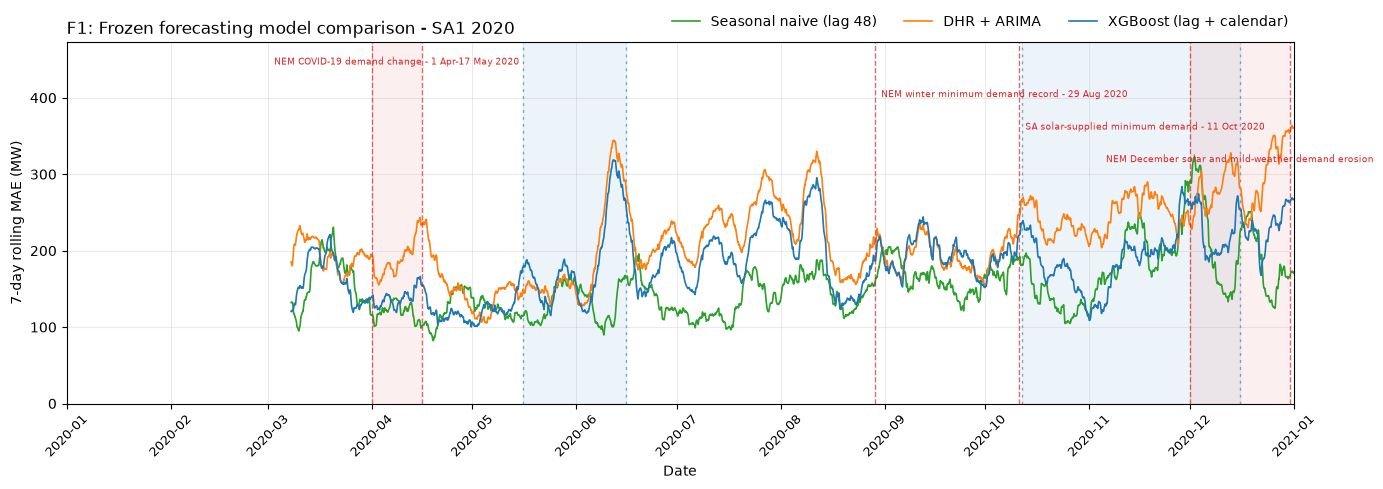

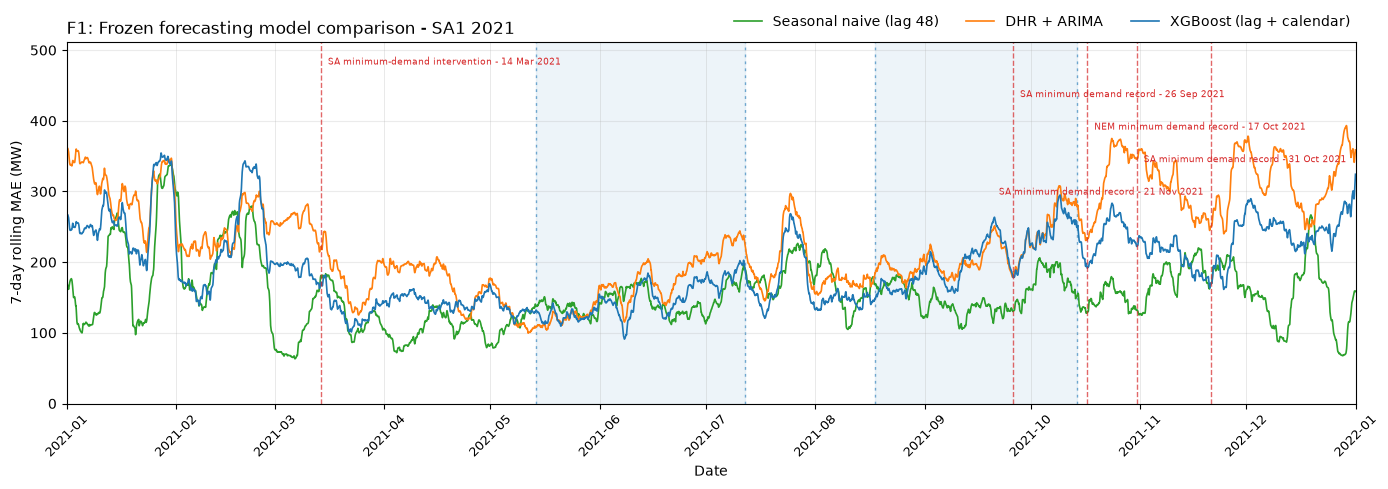

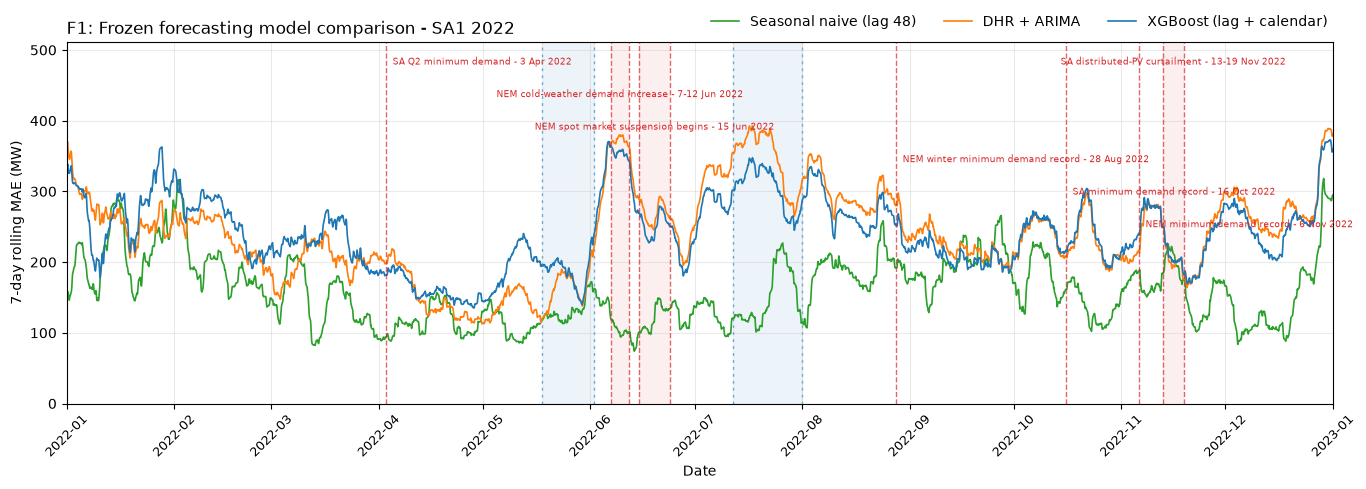

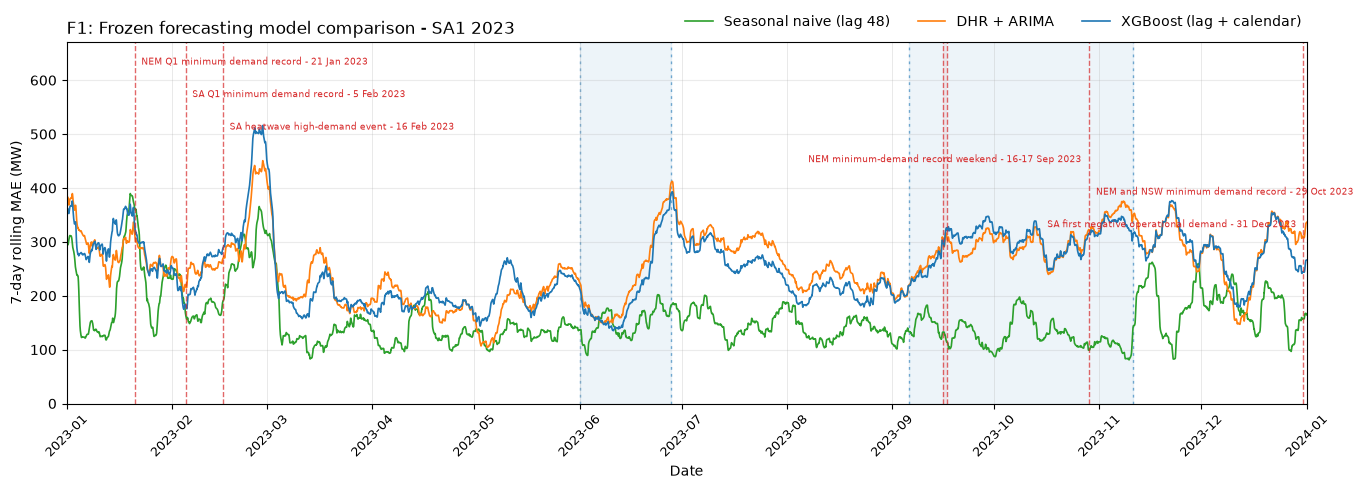

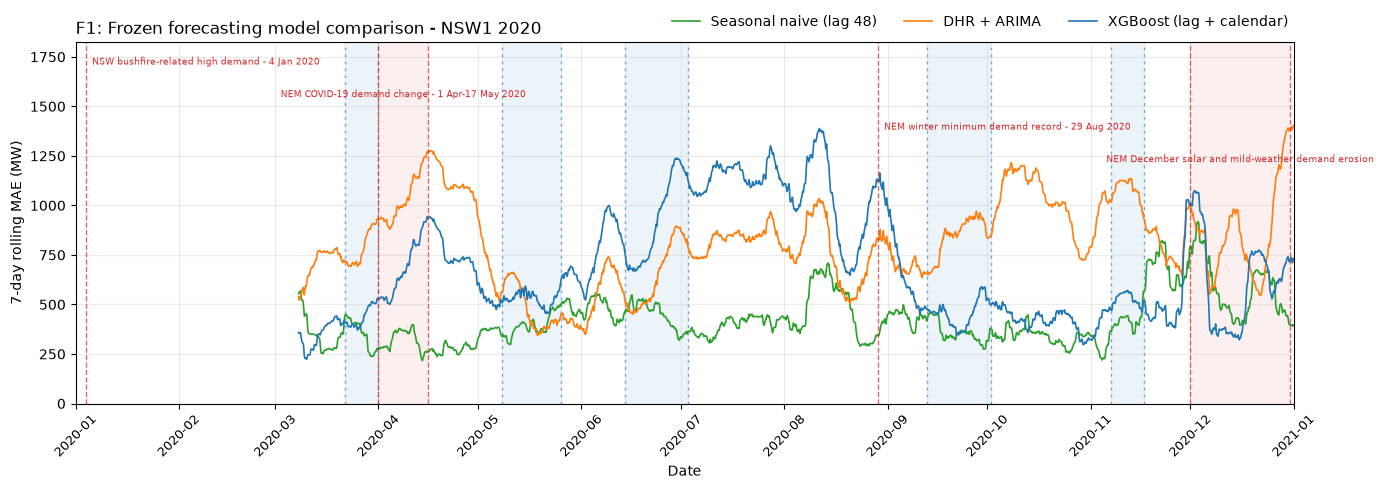

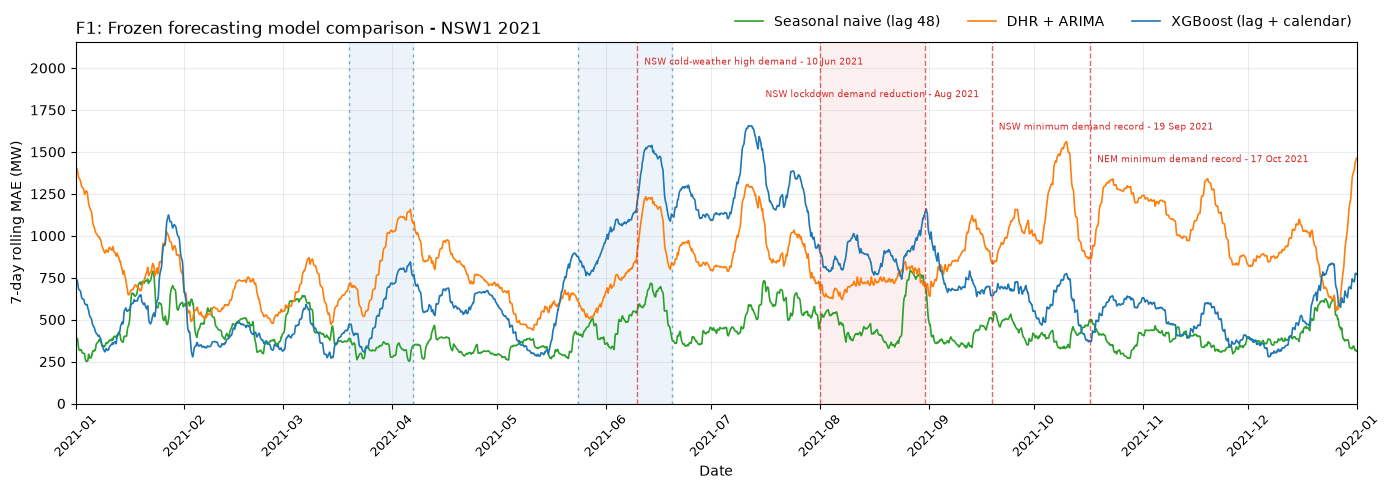

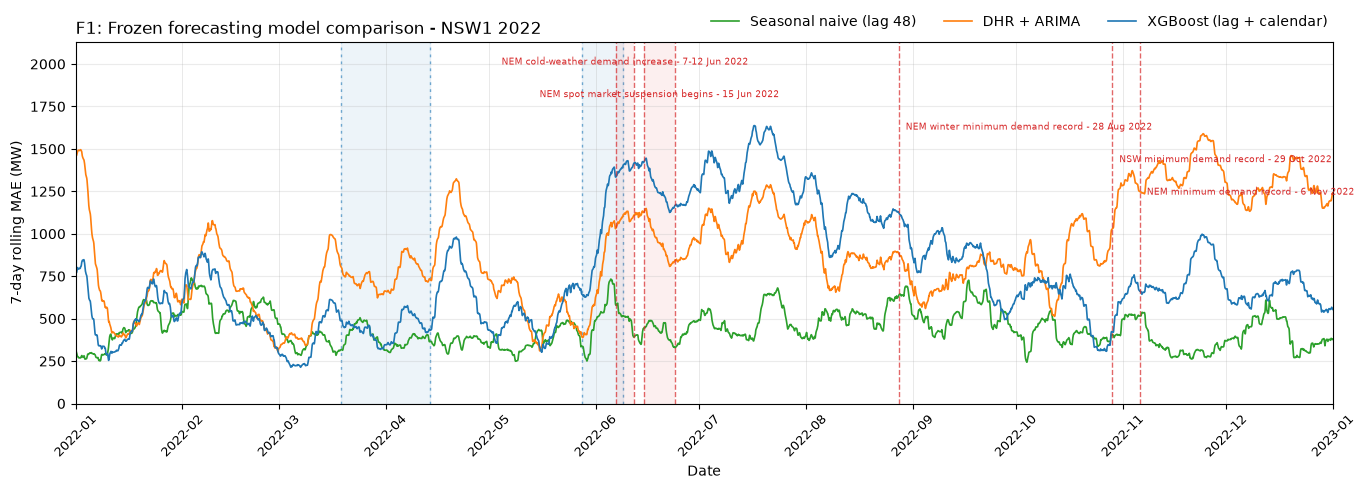

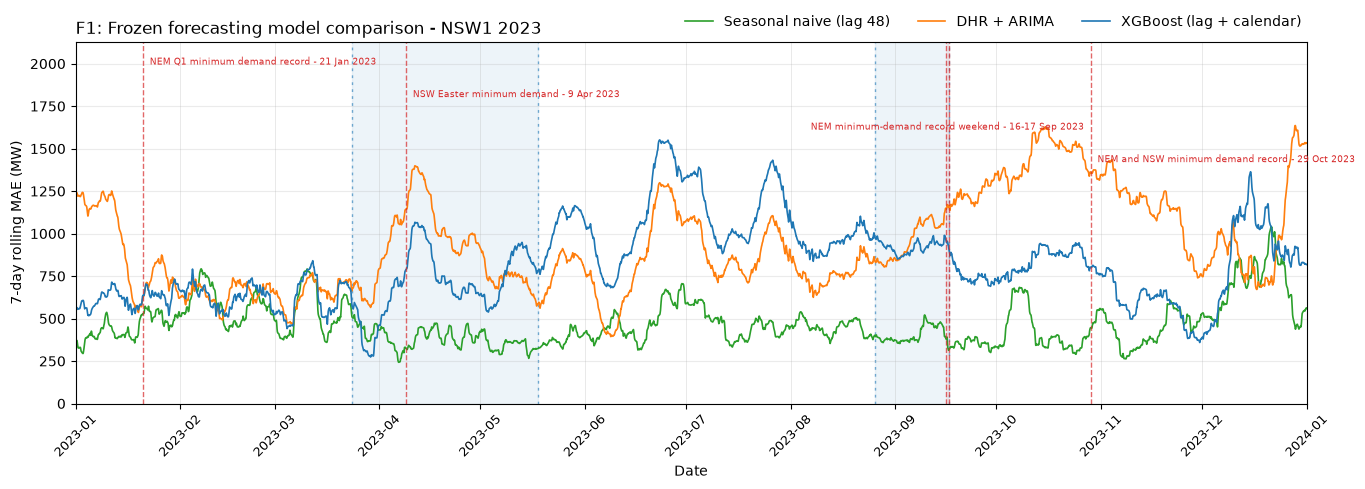

In [7]:
def format_month_axis(ax: plt.Axes, year: int) -> None:
    """Set the x-axis to exactly one calendar year with monthly ticks and a light grid."""
    ax.set_xlim(pd.Timestamp(year=year, month=1, day=1),
                pd.Timestamp(year=year + 1, month=1, day=1))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.grid(alpha=0.25)
    ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)


def plot_region_year(region: str, year: int) -> None:
    """Draw and save one region-year panel: the 3 model lines + blue degradation bands + red events."""
    fig, ax = plt.subplots(figsize=(14, 5))

    year_max = 0.0
    for key, spec in MODELS.items():   # one line per model, clipped to this year
        series = curves[region][key]
        year_series = series[series.index.year == year]
        ax.plot(year_series.index, year_series.values, label=spec["label"],
                color=spec["color"], linewidth=1.2)
        if year_series.notna().any():
            year_max = max(year_max, year_series.max())

    if year_max > 0:
        ax.set_ylim(0, year_max * 1.30)   # headroom for the event labels along the top

    annotate_degradation(ax, region, year)   # blue bands first (behind the lines)
    annotate_events(ax, region, year)        # red event markers on top

    ax.set_title(
        f"F1: Frozen forecasting model comparison - {region} {year}", loc="left"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("7-day rolling MAE (MW)")
    format_month_axis(ax, year)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.02),   # model lines only
              ncol=len(MODELS), frameon=False, borderaxespad=0.0)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"f1_comparison_{region}_{year}.png",
                dpi=130, bbox_inches="tight")
    plt.show()


for region in REGIONS:
    for year in TEST_YEARS:
        plot_region_year(region, year)


**What the per-year panels show:** in 2020 and 2021 the three lines share a floor and mostly separate only at the seasonal peaks, which come back afterwards. From 2022 the two learned models sit on a visibly higher baseline year-round. The **blue bands** mark the short transitions where that shift happens — mostly at the start of a winter or summer, before the peak.

The two regions' peaks are in opposite seasons — SA1's model-to-model spread is widest in summer (Nov–Feb), NSW1's in winter (Jun–Oct), when both learned models (DHR+ARIMA especially) badly under-track cold-weather heating demand.

Against the documented events: only NSW1's short **22 Mar – 1 Apr 2020** window butts up against a red marker (the COVID demand-change window opening 1 Apr). Every other blue window falls on a broad seasonal turn, not on a documented event — the rooftop-solar minimum-demand records in particular line up with nothing. The **June 2022 NEM market-suspension window** overlaps NSW1's sharp winter-2022 transition — circumstantial, not established.

**Suggested caption:** Seven-day rolling mean absolute error (336 half-hourly forecasts) of three frozen forecasting baselines over the test stream, per region — a full-period panel and one panel per calendar year. Blue bands mark degradation windows (the transition where the error steps up to a new level, not the elevated stretch that follows); red marks documented AEMO/AER events. Neither is a ground-truth changepoint.